In [16]:
from matplotlib import pyplot as plt
import numpy as np
from scipy import special

__Electric and magnetic fields vary as $$E_z = E_0 J_0 (\frac{j_{0 1}}{a} r)$$ and $$H_{\phi} = \frac{E_0}{Z_0} J_1 (\frac{j_{0 1}}{a} r)$$__

In [17]:
# define our variables here
r = np.linspace(0, 8, 20)
z = np.linspace(-8,8,20)

a = 8
E_0 = 10
Z_0 = 1

In [18]:
def function_of_E (E_0, z, r, a):
    E = E_0 * special.jv(0, ((special.jn_zeros(0, 1)/a) * r))
    return E

#plt.plot(r, function_of_E(E_0, z, r, a))
#plt.xlabel('$r$')
#plt.ylabel('$E_z$')
#plt.show()

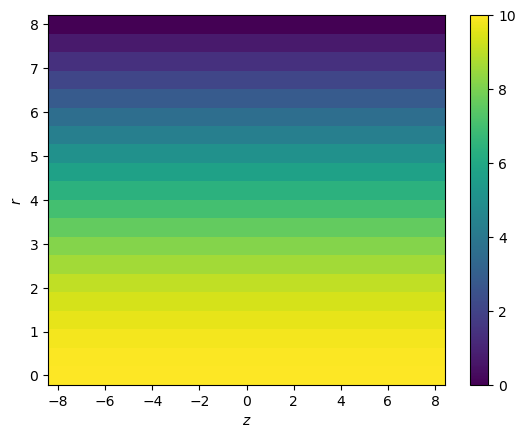

In [19]:
Z,R = np.meshgrid(z,r)

E = function_of_E(E_0, Z,R, a)

plt.pcolormesh(Z,R,E, label='E')
plt.colorbar()

#plt.legend()
plt.xlabel('$z$')
plt.ylabel('$r$')
plt.show()

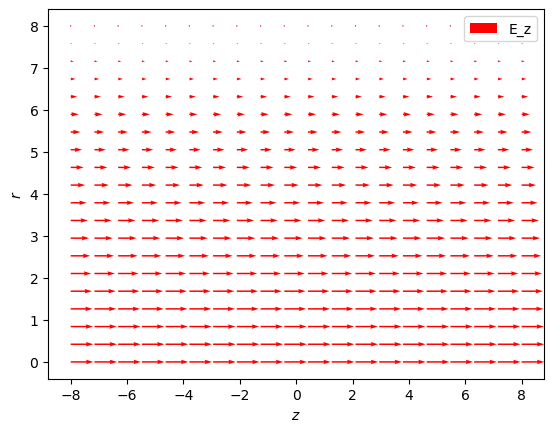

In [20]:
# some documentation: quiver([X, Y], U, V, [C], /, **kwargs)
#X, Y define the arrow locations, U, V define the arrow directions, 
# and C optionally sets the color. The arguments X, Y, U, V, C are 
# positional-only. 
# ex) ax.quiver(x, y, z, u, v, w, length=0.3, normalize=True, linewidth=0.5)

plt.quiver(Z, R, function_of_E(E_0, Z,R, a), 0, color='red', label='E_z')

plt.legend()
plt.xlabel('$z$')
plt.ylabel('$r$')
plt.show()

Similarly, for H:

<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_249614/2664825959.py:15: SyntaxWarning: invalid escape sequence '\p'
  plt.quiver(Z,R, function_of_H(E_0, Z_0, Z,R, a), 0, color='red', label='$H_{\phi}$')


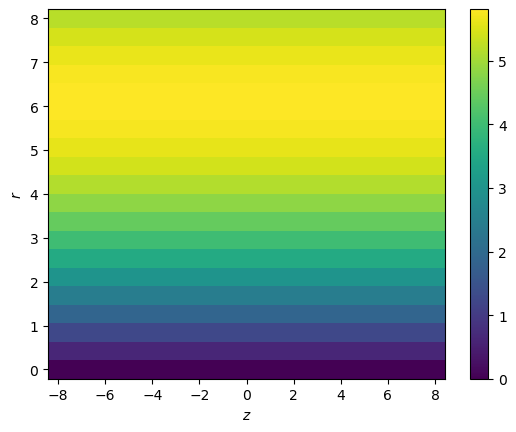

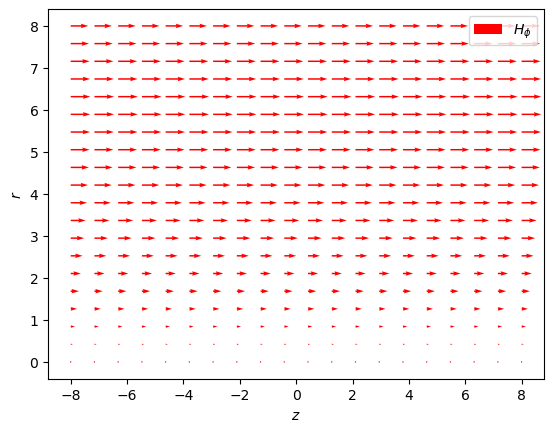

In [22]:
def function_of_H (E_0, Z_0, z, r, a):
    H = (E_0 / Z_0) * special.jv(1, ((special.jn_zeros(0, 1)/a) * r))
    return H

H = function_of_H(E_0, Z_0, Z,R, a)

plt.pcolormesh(Z,R,H, label='H')
plt.colorbar()

#plt.legend()
plt.xlabel('$z$')
plt.ylabel('$r$')
plt.show()

plt.quiver(Z,R, function_of_H(E_0, Z_0, Z,R, a), 0, color='red', label='$H_{\phi}$')

plt.legend()
plt.xlabel('$z$')
plt.ylabel('$r$')
plt.show()

Here's another representation of the H field:

<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_249614/4287285051.py:15: SyntaxWarning: invalid escape sequence '\p'
  plt.quiver(X,Y, H_x, H_y, color='red', label='$H_{\phi}$')


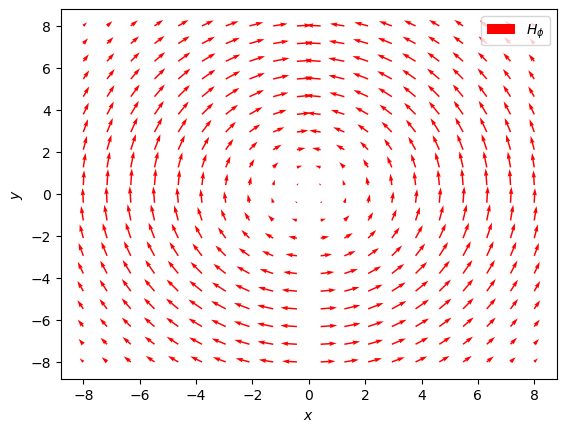

In [185]:
x_vals = np.linspace(-8, 8, 20)
y_vals = np.linspace(-8, 8, 20)
X, Y = np.meshgrid(x_vals, y_vals)

# components of the H field in the x and y directions are
# perpindicular to the radial vector. phi = 90 - theta

theta = np.arctan(Y / X)
phi = (np.pi / 2) + theta
radius = np.sqrt(X**2 + Y**2)

H_x = function_of_H(E_0, Z_0, 1,radius, a) * np.cos(phi)
H_y = function_of_H(E_0, Z_0, 1,radius, a) * np.sin(phi)

plt.quiver(X,Y, H_x, H_y, color='red', label='$H_{\phi}$')

#plt.quiver(Z,R, function_of_H(E_0, Z_0, Z,R, a), 0, color='red', label='$H_{\phi}$')
plt.legend()
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.show()

Expanding on this geometry a bit, we know that $$E_r = E_{\phi} = 0$$, since the electric field is fully longitudinal (we are considering a TM mode). On the other hand, $$H_z = H_r = 0$$. Using our above expressions for the missing componenets of each, we can make a 3D plot or two:

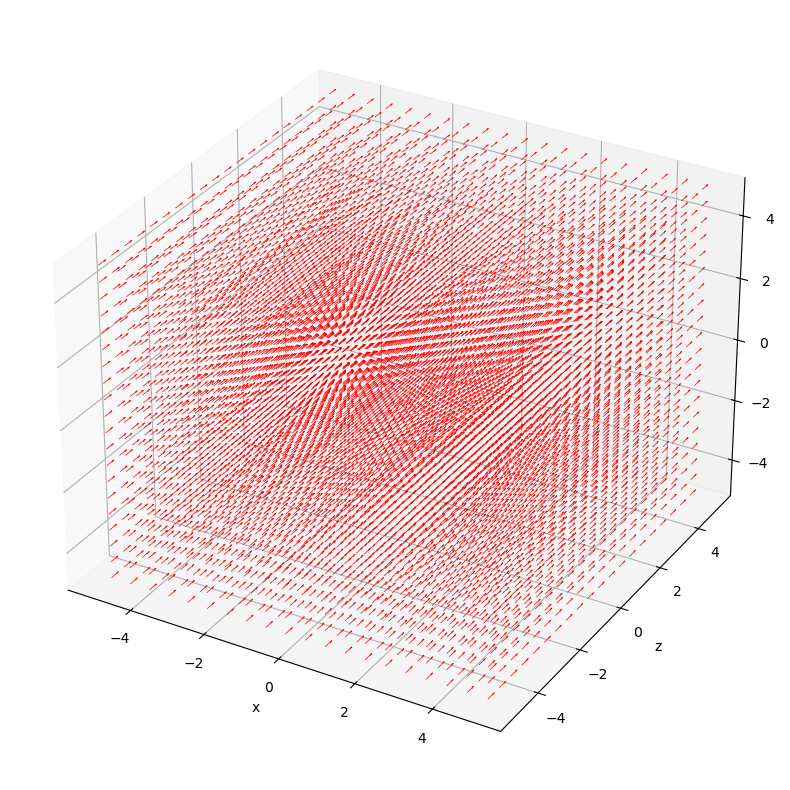

In [ ]:
x_vals = np.linspace(-5,5,20)
y_vals = np.linspace(-5,5,20)
z_vals = np.linspace(-5,5,20)

x,y,z = np.meshgrid(x_vals,y_vals,z_vals)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

# magnitudes
u = 0
v = 0
w = function_of_E(E_0, 1,1, a)

ax.quiver(x, z, y, u, w, v, color='red', length=0.3, normalize=True, linewidth=0.5)

plt.xlabel('x')
plt.ylabel('z')
plt.show()

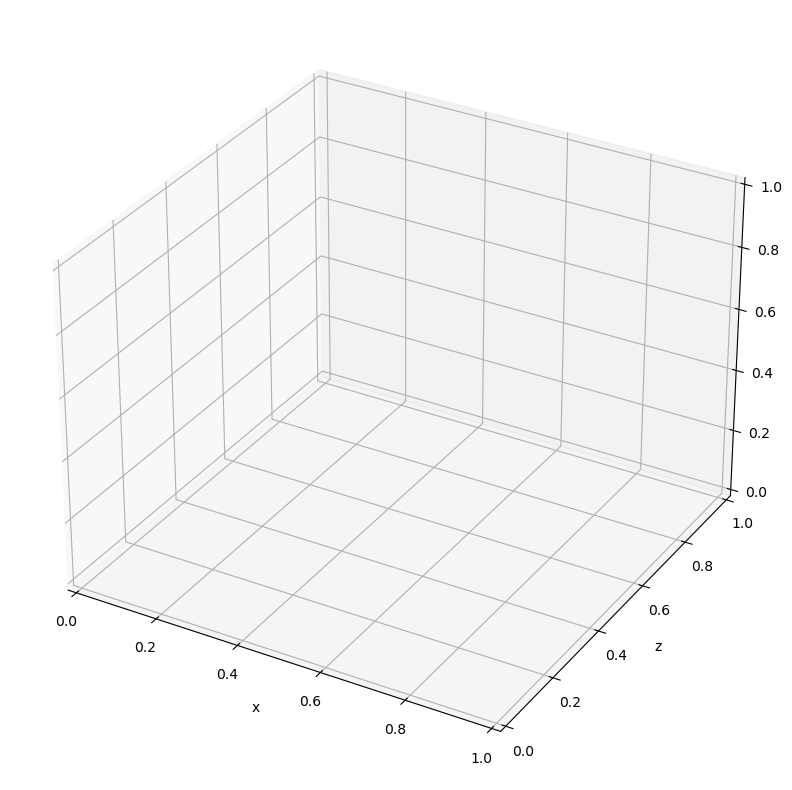

In [ ]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

for phi in np.linspace(0, 2 * np.pi, 20):
    H_phi = function_of_H(E_0, Z_0, Z,R, a)

#transforming coordinates
#H_x, H_z, H_y = polarTocartesian(H_rho, H_phi, H_z, phi)

# magnitudes
#u = H_x
#v = H_y
w = 0

#ax.quiver(x, z, y, u, w, v, color='red', length=0.3, normalize=True, linewidth=0.5)

plt.xlabel('x')
plt.ylabel('z')
plt.show()